In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2
from scipy.interpolate import interp1d
from scipy.special import factorial
import os
import sys
sys.path.append('/home/astridaurora/HESE-7-year-data-release/HESE-7-year-data-release')
from Astrid.effective_area import bin_edges_to_centers, bin_centers_to_edges, apply_energy_smearing
#import nuSIprop

import emcee
import corner
import json

In [3]:
print(np.log(1e2))

4.605170185988092


In [2]:
def center(x):
    x = np.asarray(x)
    return (x[1:] + x[:-1]) / 2.0

energy_bins = np.logspace(2, 7, 5 * 20 + 1)  # 1e2 to 1e7 with 20 bins per decade
energy_bin_widths = np.diff(energy_bins)
energy_centers = center(energy_bins)

def BPL_flux(energies=energy_centers, norm=2.28, si1=1.72, si2=2.839, E_break=10**4.524):
    # BPL model flux
    # Normalized at E = 100TeV = 1e5 GeV
    # Best fit MESE: norm = 2.28, si1 = 1.72, si2 = 2.839, E_break = 10**(4.524) GeV
    norm = norm*1e-18
    E0 = 1e5
    if E_break > 1e5:
        norm_break  = norm * (E_break / E0)**(-si1)
    else:
        norm_break  = norm * (E_break / E0)**(-si2)
    
    # If used for integration within the bin, energies will be a single value.
    if isinstance(energies, float):
        if energies < E_break:
            flux = norm_break * (energies / E0)**(-si1)
        else:
            flux = norm_break * (energies / E0)**(-si2)
    else:
        flux = np.zeros(len(energies))
        for i, E in enumerate(energies):
            if E < E_break:
                flux[i] = norm_break * (E / E_break)**(-si1)
            else:
                flux[i] = norm_break * (E / E_break)**(-si2)
    return flux 

    
def LP_flux(energies=energy_centers, norm=2.58, alpha=2.669, beta=0.359):
    # Log Parabola model flux
    # Normalized at E = 100TeV
    # Best fit MESE: norm = 2.42, alpha = 2.05, beta = 2.54
    E0 = 1e5
    norm = norm*1e-18
    return  norm * (energies / E0)**(-alpha - beta * np.log10(energies / E0)) 

def SPL_flux(energies=energy_centers, norm=2.28, si=2.548):
    # Single Power Law model flux
    # Normalized at E = 100TeV
    # Best fit MESE: norm = 2.28, si = 1.72
    E0 = 1e5
    return norm * (energies / E0)**(-si)

1. Divide each flavor in interaction types

2. Multiply each flavor-interaction catergory of flux by the corresponding effective area.

3. Convert to morphologies.

4. Apply resolution per morphology.

5. 
a. Sum all events + bin + compare to HESE12.
b. Bin + Compare to HESE12 for cascades vs tracks. 

['/home/astridaurora/nuSIprop', '/home/astridaurora/HESE-7-year-data-release/HESE-7-year-data-release/Astrid/resources/external/', '/home/astridaurora/miniforge3/envs/nusiprop/lib/python39.zip', '/home/astridaurora/miniforge3/envs/nusiprop/lib/python3.9', '/home/astridaurora/miniforge3/envs/nusiprop/lib/python3.9/lib-dynload', '', '/home/astridaurora/.local/lib/python3.9/site-packages', '/home/astridaurora/miniforge3/envs/nusiprop/lib/python3.9/site-packages', '/home/astridaurora/HESE-7-year-data-release/HESE-7-year-data-release', '/home/astridaurora/HESE-7-year-data-release/HESE-7-year-data-release']


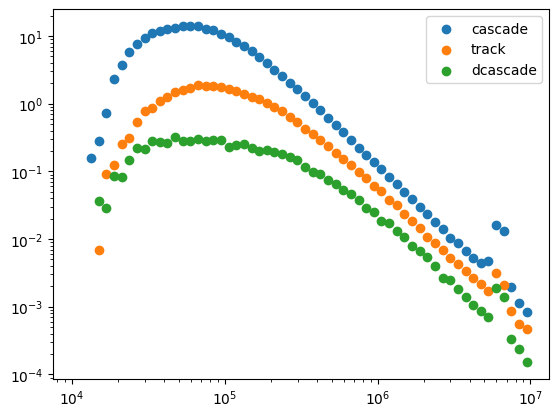

In [14]:
print(sys.path)
e_casc = pd.read_csv('/home/astridaurora/HESE-7-year-data-release/HESE-7-year-data-release/effective_areas/2nue_cascade_effective_area.csv')['effective_area_m2']
e_track = pd.read_csv('/home/astridaurora/HESE-7-year-data-release/HESE-7-year-data-release/effective_areas/2nue_track_effective_area.csv')['effective_area_m2']
e_dcasc = pd.read_csv('/home/astridaurora/HESE-7-year-data-release/HESE-7-year-data-release/effective_areas/2nue_double_cascade_effective_area.csv')['effective_area_m2']

mu_casc = pd.read_csv('/home/astridaurora/HESE-7-year-data-release/HESE-7-year-data-release/effective_areas/2numu_cascade_effective_area.csv')['effective_area_m2']
mu_track = pd.read_csv('/home/astridaurora/HESE-7-year-data-release/HESE-7-year-data-release/effective_areas/2numu_track_effective_area.csv')['effective_area_m2']
mu_dcasc = pd.read_csv('/home/astridaurora/HESE-7-year-data-release/HESE-7-year-data-release/effective_areas/2numu_double_cascade_effective_area.csv')['effective_area_m2']

tau_casc = pd.read_csv('/home/astridaurora/HESE-7-year-data-release/HESE-7-year-data-release/effective_areas/2nutau_cascade_effective_area.csv')['effective_area_m2']
tau_track = pd.read_csv('/home/astridaurora/HESE-7-year-data-release/HESE-7-year-data-release/effective_areas/2nutau_track_effective_area.csv')['effective_area_m2']
tau_dcasc = pd.read_csv('/home/astridaurora/HESE-7-year-data-release/HESE-7-year-data-release/effective_areas/2nutau_double_cascade_effective_area.csv')['effective_area_m2']

eff_casc = e_casc + mu_casc + tau_casc
eff_track = e_track + mu_track + tau_track
eff_dcasc = e_dcasc + mu_dcasc + tau_dcasc


spl_flux = SPL_flux()

spl_events_casc = SPL_flux() * eff_casc
spl_events_track = SPL_flux() * eff_track
spl_events_dcasc = SPL_flux() * eff_dcasc

plt.scatter(energy_centers[40:], spl_events_casc[40:], label='cascade')
plt.scatter(energy_centers[40:], spl_events_track[40:], label='track')
plt.scatter(energy_centers[40:], spl_events_dcasc[40:], label='dcascade')
plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.show()







100
100
1948.3242481686657
1948.3242481686657


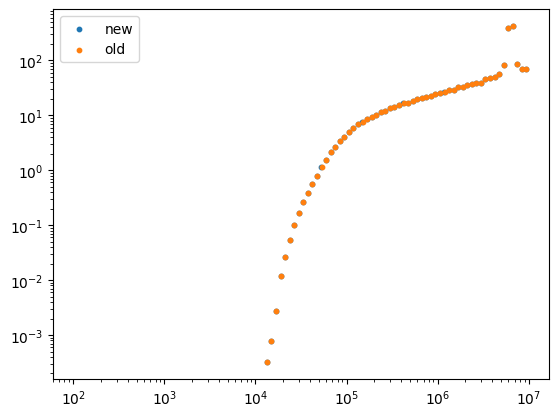

In [45]:
print(len(eff_casc))
print(len(cascades['effective_area_m2']))


tota_area_casc = np.sum(cascades['effective_area_m2'])

print(tota_area_casc)
print(np.sum(eff_casc))


energy_bins = np.logspace(2, 7, 101)
energy_centers = center(energy_bins)

plt.scatter(cascades['energy_bins'], cascades['effective_area_m2'], label='new', s=10)
plt.scatter(energy_centers, eff_casc, label='old', s=10)
plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.show()



80
RangeIndex(start=0, stop=80, step=1)
80 80 80


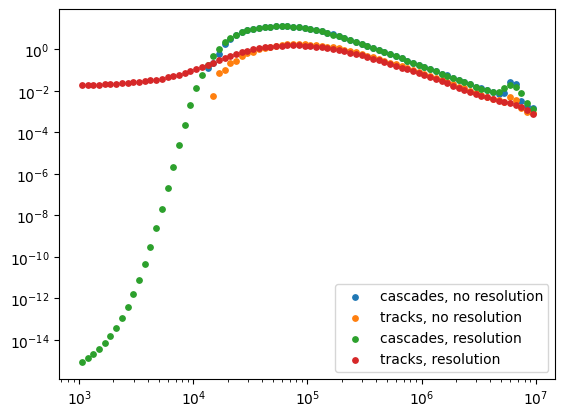

In [5]:
cascades = pd.read_csv('/home/astridaurora/HESE-7-year-data-release/HESE-7-year-data-release/effective_areas/All flavors cascade_effective_area.csv')['effective_area_m2'].iloc[0:].reset_index(drop=True)
tracks = pd.read_csv('/home/astridaurora/HESE-7-year-data-release/HESE-7-year-data-release/effective_areas/All flavors track_effective_area.csv')['effective_area_m2'].iloc[0:].reset_index(drop=True)
dcascades = pd.read_csv('/home/astridaurora/HESE-7-year-data-release/HESE-7-year-data-release/effective_areas/All flavors double_cascade_effective_area.csv')['effective_area_m2'].iloc[0:].reset_index(drop=True)
energies = pd.read_csv('/home/astridaurora/HESE-7-year-data-release/HESE-7-year-data-release/effective_areas/All flavors cascade_effective_area.csv')['energy_bins'].iloc[0:].reset_index(drop=True)
print(len(energies))
print(cascades.index)

spl_flux = SPL_flux(energies=energies)
print(len(spl_flux), len(cascades), len(energies))


casc_smeared = apply_energy_smearing(energies=np.asarray(energies), events=spl_flux * np.asarray(cascades), resolution=0.11)
track_smeared = apply_energy_smearing(energies=np.asarray(energies), events=spl_flux * np.asarray(tracks), resolution=0.30)


#plt.scatter(cascades['energy_bins'], spl_flux1)
#plt.scatter(cascades['energy_bins'], cascades['effective_area_m2'], label='effective area', s=15)
plt.scatter(energies,  spl_flux * cascades, label='cascades, no resolution', s=15)
plt.scatter(energies, spl_flux * tracks, label='tracks, no resolution', s=15)
plt.scatter(energies, casc_smeared, label='cascades, resolution', s=15)
plt.scatter(energies, track_smeared, label='tracks, resolution', s=15)
plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.show()


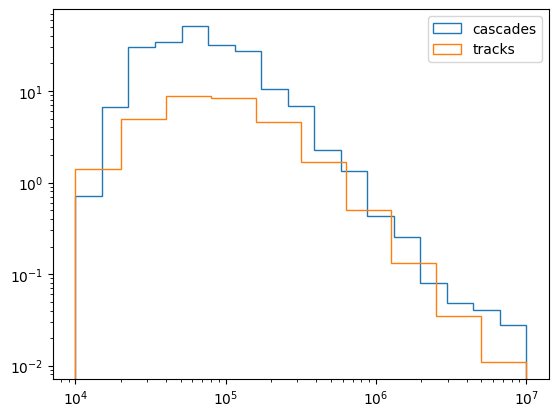

In [60]:
ecasc_bins_low_res = np.logspace(4, 7, 17+1)
etrack_bins_low_res = np.logspace(4, 7, 10+1)

plt.hist(energies, bins=ecasc_bins_low_res, weights=casc_smeared, label='cascades', histtype='step')
plt.hist(energies, bins=etrack_bins_low_res, weights=track_smeared, label='tracks', histtype='step')
plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.show()


In [4]:
mc_filenames = [
    "./resources/data/HESE_mc_observable.json",
    "./resources/data/HESE_mc_flux.json",
    "./resources/data/HESE_mc_truth.json",
]

json_data = dict()
for filename in mc_filenames:
    json_data.update(json.load(open(filename, "r")))

In [23]:
#print(json_data[json_data['primaryType'] == 13])
flag = any(x != 0 for x in json_data['muonWeightOverLivetime'])
print(flag)

True


In [ ]:
morph_frac = {
    "cascade": 0.727,
    "track": 0.234,
    "dcascade": 0.039
}

flavor_given_morph = {
    "cascade": {"nu_e": 0.567, "nu_mu": 0.157, "nu_tau": 0.276},
    "track": {"nu_e": 0.098, "nu_mu": 0.728, "nu_tau": 0.105},
    "dcascade": {"nu_e": 0.211, "nu_mu": 0.142, "nu_tau": 0.647}
}


cc_flavor_given_morph = {
    "cascade": {"nu_e": 0.519, "nu_mu": 0.087, "nu_tau": 0.236},
    "track": {"nu_e": 0.088, "nu_mu": 0.716, "nu_tau": 0.098},
    "dcascade": {"nu_e": 0.182, "nu_mu": 0.109, "nu_tau": 0.629}
}

interaction_given_morph = {
    "cascade": {"CC": 0.843, "NC": 0.148, "GR": 0.009},
    "track": {"CC": 0.902, "NC": 0.026, "GR": 0.003},
    "dcascade": {"CC": 0.920, "NC": 0.069, "GR": 0.012}
}

In [ ]:
energy_bins = np.logspace(4, 7, 3*20+1)
energy_centers = bin_edges_to_centers(energy_bins)
energy_bins_low_resolution = np.logspace(4, 7, 20+1)
energy_centers_low_resolution = bin_edges_to_centers(energy_bins_low_resolution)

livetime12 = 12*365*24*3600

hese12_events_df = pd.read_csv('4_to_7_HESE12/20bins/hese12_20bins_df.csv', index_col=0)
print(hese12_events_df)

cascade_data_df = pd.read_csv('4_to_7_HESE12/20bins/cascade_events_12.csv', index_col=0)
track_data_df = pd.read_csv('4_to_7_HESE12/20bins/track_events_12.csv', index_col=0)
dcascade_data_df = pd.read_csv('4_to_7_HESE12/20bins/dcascade_events_12.csv', index_col=0)


background_df = pd.read_csv('4_to_7_HESE12/20bins/background_20bins_df.csv', index_col=0)
background_df.rename(columns={'background': 'events'}, inplace=True)

cascade_background_df = pd.read_csv('4_to_7_HESE12/20bins/background_cascade_events_12.csv', index_col=0)
track_background_df = pd.read_csv('4_to_7_HESE12/20bins/background_track_events_12.csv', index_col=0)
dcascade_background_df = pd.read_csv('4_to_7_HESE12/20bins/background_dcascade_events_12.csv', index_col=0)


In [ ]:
def events_by_flavor_and_interaction(flx, eff, livetime, norm, delta_E):
    # Interpolate `flx` to the same energy bins as `eff`
    flx_interpolated = pd.DataFrame(
    {col: interp1d(flx.index, flx[col], bounds_error=False, fill_value="extrapolate")(eff.index)
     for col in flx.columns},
    index=eff.index)
    
    """for key in eff.keys():
        if eff[key].any() < 0:
            print('Negative effective area found')"""
            
    #print(flx_interpolated.shape, eff.shape, delta_E.shape)    
    
    events_df = flx_interpolated * eff * livetime * norm 
    #print(events_df)
    
    for key in events_df.keys():
        
        if events_df[key].any() < 0:
            print('Negative events found')
            negative_mask = events_df[key] < 0
            events_df[key][negative_mask] = 0
        
        events_df[key] = events_df[key] * delta_E

    return events_df


def compute_interaction_fractions_df(flx_df, morph_frac, interaction_given_morph, cc_flavor_given_morph, flavor_given_morph):
    """
    Compute interaction-type fractions (CC, NC, GR) for each flavor across energy bins in a flux DataFrame.

    Parameters:
        flx_df (pd.DataFrame): DataFrame of shape (E, 3), with columns ['nu_e', 'nu_mu', 'nu_tau']
        morph_frac (dict): Fraction of events per morphology
        interaction_given_morph (dict): Fraction of CC, NC, GR within each morphology
        cc_flavor_given_morph (dict): Flavor composition of CC events within each morphology
        flavor_given_morph (dict): Flavor composition of all events in each morphology

    Returns:
        pd.DataFrame: Shape (E, 9), with columns like 'nu_e_CC', 'nu_e_NC', 'nu_e_GR', ..., 'nu_tau_GR'
    """
    flavors = ['nu_e', 'nu_mu', 'nu_tau']
    interactions = ['CC', 'NC', 'GR']
    morphologies = morph_frac.keys()

    # Precompute weights N[flav][intxn] = sum over morphologies of (morph_frac * P(intxn|morph) * P(flav|intxn,morph))
    weights = {flav: {intxn: 0.0 for intxn in interactions} for flav in flavors}

    for morph in morphologies:
        f_morph = morph_frac[morph]
        for intxn in interactions:
            p_intxn = interaction_given_morph[morph][intxn]
            for flav in flavors:
                if intxn == 'CC':
                    p_flav = cc_flavor_given_morph[morph][flav]
                else:
                    p_flav = flavor_given_morph[morph][flav]
                weights[flav][intxn] += f_morph * p_intxn * p_flav

    # Convert weights to fractions per flavor
    frac = {flav: {} for flav in flavors}
    for flav in flavors:
        total = sum(weights[flav][intxn] for intxn in interactions)
        for intxn in interactions:
            frac[flav][intxn] = weights[flav][intxn] / total if total > 0 else 0.0

    # Apply fractions to flux dataframe
    result_dict = {}
    for flav in flavors:
        for intxn in interactions:
            col_name = f"{flav}_{intxn}"
            result_dict[col_name] = flx_df[flav] * frac[flav][intxn]

    return pd.DataFrame(result_dict, index=flx_df.index)



def convert_flux_to_morphologies(intxn_df, morph_frac, interaction_given_morph, cc_flavor_given_morph, flavor_given_morph):
    """
    Converts a DataFrame with 9 columns (flavor-interaction pairs) into morphology fluxes (cascade, track, dcascade).
    
    Parameters:
        intxn_df (pd.DataFrame): Flux DataFrame with columns like 'nu_e_CC', 'nu_mu_NC', ..., shape (E, 9)
        morph_frac (dict): Fraction of total events per morphology
        interaction_given_morph (dict): Fraction of each interaction per morphology
        cc_flavor_given_morph (dict): Flavor composition of CC events within each morphology
        flavor_given_morph (dict): Flavor composition of total events within each morphology

    Returns:
        pd.DataFrame: Flux per morphology, columns = ['cascade', 'track', 'dcascade'], shape (E, 3)
    """
    flavors = ['nu_e', 'nu_mu', 'nu_tau']
    interactions = ['CC', 'NC', 'GR']
    morphologies = list(morph_frac.keys())

    # Build P(morph | flavor, interaction)
    P_morph_given_flav_intxn = {}
    for flav in flavors:
        for intxn in interactions:
            weights = {}
            for morph in morphologies:
                p_morph = morph_frac[morph]
                p_intxn_given_morph = interaction_given_morph[morph][intxn]
                if intxn == 'CC':
                    p_flav_given_morph_intxn = cc_flavor_given_morph[morph][flav]
                else:
                    p_flav_given_morph_intxn = flavor_given_morph[morph][flav]

                weights[morph] = p_morph * p_intxn_given_morph * p_flav_given_morph_intxn

            # Normalize
            total = sum(weights.values())
            if total > 0:
                normed = {m: weights[m]/total for m in morphologies}
            else:
                normed = {m: 0.0 for m in morphologies}
            P_morph_given_flav_intxn[(flav, intxn)] = normed

    # Initialize output
    out_df = pd.DataFrame(0.0, index=intxn_df.index, columns=morphologies)

    for flav in flavors:
        for intxn in interactions:
            col = f"{flav}_{intxn}"
            if col not in intxn_df.columns:
                continue
            for morph in morphologies:
                weight = P_morph_given_flav_intxn[(flav, intxn)][morph]
                out_df[morph] += intxn_df[col] * weight

    return out_df



In [ ]:
def log_Jeffreys_prior(theta):
    #Mphi, g, mntot, si, norm = theta
    #Mphi, g, si, norm = theta
    Mphi, g, si = theta
    
    # Use log-uniform priors for better exploration
    if not (1e-4 < g < 1):
        return -np.inf
    if not (0.1 < Mphi < 1000):
        return -np.inf
    #if not (0.06 < mntot < 0.12):
    #    return -np.inf
    if not (2.0 < si < 3.0):
        return -np.inf
    #if not (1e-19 < norm < 1e-17):  # Much wider range
    #    return -np.inf
    
    # Log-uniform prior: log(1/x) = -log(x)
    #return -np.log(g) - np.log(Mphi) - np.log(norm)
    return -np.log(g) - np.log(Mphi)
    

def log_prior_uniform(theta):
    """
    Uniform prior (for comparison)
    """
    #Mphi, g, mntot, si, norm = theta
    #Mphi, g, si, norm = theta
    Mphi, g, si = theta
    
    # Check bounds
    if not (1e-4 < g < 1):
        return -np.inf
    if not (0.1 < Mphi < 1000):
        return -np.inf
    #if not (0.06 < mntot < 0.12):
    #    return -np.inf
    if not (2.0 < si < 3.0):
        return -np.inf
    #if not (1e-19 < norm < 1e-17):
    #    return -np.inf
    
    # Uniform prior (constant)
    return 0.0


def log_likelihood_poisson(data, predicted):
    # From Poisson distribution 
    return np.sum(-predicted + data*np.log(predicted) - np.log(factorial(data)))


def log_likelihood_original(theta):
    Mphi, g, si = theta

    evolver.set_parameters(mphi=Mphi*1e6, g=g, si=si)
    evolver.evolve()
    flux = evolver.get_flux_fla()

    flx_df = pd.DataFrame(flux.T, index=energies, columns=['nu_e', 'nu_mu', 'nu_tau'])
    flx_df.index = flx_df.index / 1e9

    nuSIprop_df = events_by_flavor_and_interaction(flx=effective_area_original_df, eff=flx_df, livetime=livetime12, norm=1e-4, delta_E=delta_E)
    nuSIprop_df['total_events'] = nuSIprop_df['nu_e'] + nuSIprop_df['nu_mu'] + nuSIprop_df['nu_tau']
    nuSIprop_smeared = apply_energy_smearing(energies=nuSIprop_df.index.values, events=nuSIprop_df['total_events'].values, resolution=0.1)

    nuSIprop_binned_events, _ = np.histogram(nuSIprop_df.index.values, weights=nuSIprop_smeared, bins=energy_bins_low_resolution)
    print(nuSIprop_binned_events)
    predicted = nuSIprop_binned_events + background_df['events'].values
    print(predicted)

    return log_likelihood_poisson(data=hese12_events_df['events'].values.astype(int), predicted=predicted)


def log_likelihood_a(theta):
    # Alternative a: Sum all events, then bin, then compare to data.
    # Hence, the major difference to the original is applying different resolutions.
    
    Mphi, g, si = theta

    # Update and evolve the flux with the new parameters.
    evolver.set_parameters(mphi=Mphi*1e6, g=g, si=si)
    evolver.evolve()
    flux = evolver.get_flux_fla()
    flx_df = pd.DataFrame(flux.T, index=energies, columns=['nu_e', 'nu_mu', 'nu_tau'])
    
    # Split into interaction types.
    flx_interaction_df = compute_interaction_fractions_df(flx_df, morph_frac, interaction_given_morph, cc_flavor_given_morph, flavor_given_morph)
    flx_interaction_df.index = flx_interaction_df.index / 1e9

    # Compute the number of events for each flavor and interaction type.
    interaction_events_df = events_by_flavor_and_interaction(flx=effective_area_df, eff=flx_interaction_df, livetime=livetime12, norm=1e-4, delta_E=delta_E)
    
    # Convert to morphologies.
    morph_events_df = convert_flux_to_morphologies(
        intxn_df=interaction_events_df, 
        morph_frac=morph_frac,
        interaction_given_morph=interaction_given_morph,
        cc_flavor_given_morph=cc_flavor_given_morph,
        flavor_given_morph=flavor_given_morph
    )
    cascade_events_smeared = apply_energy_smearing(energies=morph_events_df.index.values, events=morph_events_df['cascade'].values, resolution=0.11)
    track_events_smeared = apply_energy_smearing(energies=morph_events_df.index.values, events=morph_events_df['track'].values, resolution=0.30)
    d_cascade_events_smeared = apply_energy_smearing(energies=morph_events_df.index.values, events=morph_events_df['dcascade'].values, resolution=0.18)

    cascade_binned_events, _ = np.histogram(a=morph_events_df.index.values, weights=cascade_events_smeared, bins=energy_bins_low_resolution)
    track_binned_events, _ = np.histogram(a=morph_events_df.index.values, weights=track_events_smeared, bins=energy_bins_low_resolution)
    d_cascade_binned_events, _ = np.histogram(a=morph_events_df.index.values, weights=d_cascade_events_smeared, bins=energy_bins_low_resolution)

    predicted = cascade_binned_events + track_binned_events + d_cascade_binned_events + background_df['events'].values
    
    return log_likelihood_poisson(data=hese12_events_df['events'].values.astype(int), predicted=predicted)


def log_likelihood_b(theta):
    # Alternative b: Bin, then compare to HESE12 for each morphology respectively.
    
    Mphi, g, si = theta

    # Update and evolve the flux with the new parameters.
    evolver.set_parameters(mphi=Mphi*1e6, g=g, si=si)
    evolver.evolve()
    flux = evolver.get_flux_fla()
    flx_df = pd.DataFrame(flux.T, index=energies, columns=['nu_e', 'nu_mu', 'nu_tau'])
    
    # Split into interaction types.
    flx_interaction_df = compute_interaction_fractions_df(flx_df, morph_frac, interaction_given_morph, cc_flavor_given_morph, flavor_given_morph)
    #print(flx_interaction_df)
    flx_interaction_df.index = flx_interaction_df.index / 1e9

    # Compute the number of events for each flavor and interaction type.
    interaction_events_df = events_by_flavor_and_interaction(flx=effective_area_df, eff=flx_interaction_df, livetime=livetime12, norm=1e-4, delta_E=delta_E)
    
    # Convert to morphologies.
    morph_events_df = convert_flux_to_morphologies(
        intxn_df=interaction_events_df, 
        morph_frac=morph_frac,
        interaction_given_morph=interaction_given_morph,
        cc_flavor_given_morph=cc_flavor_given_morph,
        flavor_given_morph=flavor_given_morph
    )
    cascade_events_smeared = apply_energy_smearing(energies=morph_events_df.index.values, events=morph_events_df['cascade'].values, resolution=0.11)
    track_events_smeared = apply_energy_smearing(energies=morph_events_df.index.values, events=morph_events_df['track'].values, resolution=0.30)
    d_cascade_events_smeared = apply_energy_smearing(energies=morph_events_df.index.values, events=morph_events_df['dcascade'].values, resolution=0.18)

    
    #predicted = cascade_binned_events + track_binned_events + d_cascade_binned_events + background_df['events'].values
    #print(predicted)
    
    cascade_binned_events, _ = np.histogram(a=morph_events_df.index.values, weights=cascade_events_smeared, bins=energy_bins_low_resolution)
    track_binned_events, _ = np.histogram(a=morph_events_df.index.values, weights=track_events_smeared, bins=energy_bins_low_resolution)
    d_cascade_binned_events, _ = np.histogram(a=morph_events_df.index.values, weights=d_cascade_events_smeared, bins=energy_bins_low_resolution)

    predicted_cascade = cascade_binned_events + cascade_background_df['events'].values
    predicted_track = track_binned_events + track_background_df['events'].values
    predicted_dcascade = d_cascade_binned_events + dcascade_background_df['events'].values
    
    ll_cascade = log_likelihood_poisson(data=cascade_data_df['events'].values.astype(int), predicted=predicted_cascade)
    ll_track = log_likelihood_poisson(data=track_data_df['events'].values.astype(int), predicted=predicted_track)
    ll_dcascade = log_likelihood_poisson(data=dcascade_data_df['events'].values.astype(int), predicted=predicted_dcascade)
    print(ll_cascade, ll_track, ll_dcascade)
    
    return ll_cascade + ll_track + ll_dcascade


def log_posterior(theta):

    lp = log_prior_uniform(theta)
    #lp = log_Jeffreys_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    ll = log_likelihood_a(theta)

    if np.random.random() < 0.03:  # Print 3% of calls
        print(f"Testing: Mphi={theta[0]:.2f}, g={theta[1]:.2e}, si={theta[2]:.2f}")
        print(f"Log Prior: {lp:.2f}, Log Likelihood: {ll:.2f}")
    return lp + ll